# 🎬 Video-RAG Pipeline — 
This notebook series implements the **Video-RAG** pipeline from scratch:
> *Visually-Aligned Retrieval-Augmented Long Video Comprehension*

## 📚 Pipeline Overview
```
Video + Query
     │
     ▼
┌─────────────────────────────────────┐
│  Step 2: Feature Extraction     │
│  ├── ASR  (Whisper)                 │
│  ├── OCR  (EasyOCR)                 │
│  └── Object Detection (YOLO)        │
└─────────────────┬───────────────────┘
                  │ Timestamped text chunks
                  ▼
┌─────────────────────────────────────┐
│  Step 3: Indexing & Retrieval   │
│  ├── Build BM25 index               │
│  ├── Build FAISS dense index        │
│  └── Hybrid retrieval               │
└─────────────────┬───────────────────┘
                  │ Retrieved chunks
                  ▼
┌─────────────────────────────────────┐
│  Step 4: LVLM Integration       │
│  ├── Query decoupling               │
│  ├── Context augmentation           │
│  └── Answer generation              │
└─────────────────────────────────────┘
```

## 🖥️ Recommended Runtime
- **Google Colab**: T4 GPU (free) or A100 (Pro)
- **RunPod**: RTX 3090 / A40
- RAM: 16GB+ recommended


## Step 1: Check GPU & Environment

In [1]:
import subprocess
import sys

# Check GPU
try:
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    print(result.stdout)
except FileNotFoundError:
    print('⚠️  No GPU detected. Some steps will be slow but will still work.')

# Check Python version
print(f'Python: {sys.version}')

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print('✅ Running in Google Colab')
except ImportError:
    IN_COLAB = False
    print('Running locally / RunPod')

Sun Jun 14 08:40:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Step 2: Install All Dependencies

This installs everything needed for the full pipeline:
- `yt-dlp` — download YouTube videos
- `openai-whisper` — ASR (speech-to-text)
- `easyocr` — OCR (text in frames)
- `ultralytics` — YOLOv8 object detection
- `rank_bm25` — BM25 sparse retrieval
- `faiss-cpu` — dense vector retrieval
- `sentence-transformers` — text embeddings
- `transformers` — HuggingFace LLMs
- `opencv-python` — video frame extraction

In [2]:
# Install core dependencies
!pip install -q yt-dlp openai-whisper easyocr ultralytics
!pip install -q rank_bm25 faiss-cpu sentence-transformers
!pip install -q transformers accelerate bitsandbytes
!pip install -q opencv-python-headless Pillow tqdm
!pip install -q ffmpeg-python

# Install ffmpeg system package (needed by Whisper)
import subprocess
subprocess.run(['apt-get', 'install', '-y', '-q', 'ffmpeg'],
               capture_output=True)

print('✅ All packages installed!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.8/183.8 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 32.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 106.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 118.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 105.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.6 MB/s 

## Step 3: Set Up Project Directories

In [3]:
import os
from pathlib import Path

# Project root — change this if needed
PROJECT_ROOT = Path('./video_rag_project')

# Create directory structure
dirs = [
    PROJECT_ROOT / 'videos',        # raw downloaded videos
    PROJECT_ROOT / 'frames',        # extracted frames
    PROJECT_ROOT / 'transcripts',   # ASR outputs
    PROJECT_ROOT / 'ocr_results',   # OCR outputs
    PROJECT_ROOT / 'detections',    # YOLO outputs
    PROJECT_ROOT / 'index',         # BM25 + FAISS index files
    PROJECT_ROOT / 'outputs',       # final answers
]

for d in dirs:
    d.mkdir(parents=True, exist_ok=True)

print('✅ Directory structure created:')
for d in dirs:
    print(f'   {d}')

✅ Directory structure created:
   video_rag_project/videos
   video_rag_project/frames
   video_rag_project/transcripts
   video_rag_project/ocr_results
   video_rag_project/detections
   video_rag_project/index
   video_rag_project/outputs


## Step 4: Verify Installations

In [4]:
import importlib

packages = {
    'whisper': 'openai-whisper',
    'easyocr': 'easyocr',
    'ultralytics': 'ultralytics (YOLO)',
    'rank_bm25': 'rank_bm25',
    'faiss': 'faiss-cpu',
    'sentence_transformers': 'sentence-transformers',
    'transformers': 'transformers',
    'cv2': 'opencv',
}

print('Package verification:')
print('-' * 40)
all_ok = True
for module, name in packages.items():
    try:
        importlib.import_module(module)
        print(f'  ✅  {name}')
    except ImportError:
        print(f'  ❌  {name} — MISSING')
        all_ok = False

print('-' * 40)
if all_ok:
    print('\n🎉 All packages ready! Move to Notebook 02.')
else:
    print('\n⚠️  Some packages missing — re-run Step 2.')

Package verification:
----------------------------------------
  ✅  openai-whisper
  ✅  easyocr
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
  ✅  ultralytics (YOLO)
  ✅  rank_bm25
  ✅  faiss-cpu
  ✅  sentence-transformers
  ✅  transformers
  ✅  opencv
----------------------------------------

🎉 All packages ready! Move to Notebook 02.


## Step 5: Save Config for All Notebooks

In [5]:
import json

CONFIG = {
    # Paths
    'project_root': str(PROJECT_ROOT),
    'video_dir': str(PROJECT_ROOT / 'videos'),
    'frames_dir': str(PROJECT_ROOT / 'frames'),
    'transcripts_dir': str(PROJECT_ROOT / 'transcripts'),
    'ocr_dir': str(PROJECT_ROOT / 'ocr_results'),
    'detections_dir': str(PROJECT_ROOT / 'detections'),
    'index_dir': str(PROJECT_ROOT / 'index'),
    'outputs_dir': str(PROJECT_ROOT / 'outputs'),

    # Feature extraction settings
    'whisper_model': 'base',        # tiny / base / small / medium / large
    'frame_sample_fps': 1,          # extract 1 frame per second
    'yolo_model': 'yolov8n.pt',     # nano = fastest; yolov8s/m for better accuracy
    'yolo_conf_threshold': 0.4,
    'ocr_languages': ['en'],

    # Retrieval settings
    'embedding_model': 'all-MiniLM-L6-v2',  # fast & good
    'top_k_retrieve': 5,            # how many chunks to retrieve
    'retrieval_mode': 'hybrid',     # 'bm25' | 'dense' | 'hybrid'

    # LVLM settings
    'lvlm_model': 'Qwen/Qwen2-VL-7B-Instruct',  # vision-language model
    'max_frames_to_model': 8,       # frames sent to LVLM
    'max_new_tokens': 512,
}

config_path = PROJECT_ROOT / 'config.json'
with open(config_path, 'w') as f:
    json.dump(CONFIG, f, indent=2)

print(f'✅ Config saved to {config_path}')
print()
print('Current settings:')
for k, v in CONFIG.items():
    print(f'  {k}: {v}')

✅ Config saved to video_rag_project/config.json

Current settings:
  project_root: video_rag_project
  video_dir: video_rag_project/videos
  frames_dir: video_rag_project/frames
  transcripts_dir: video_rag_project/transcripts
  ocr_dir: video_rag_project/ocr_results
  detections_dir: video_rag_project/detections
  index_dir: video_rag_project/index
  outputs_dir: video_rag_project/outputs
  whisper_model: base
  frame_sample_fps: 1
  yolo_model: yolov8n.pt
  yolo_conf_threshold: 0.4
  ocr_languages: ['en']
  embedding_model: all-MiniLM-L6-v2
  top_k_retrieve: 5
  retrieval_mode: hybrid
  lvlm_model: Qwen/Qwen2-VL-7B-Instruct
  max_frames_to_model: 8
  max_new_tokens: 512


---
## ✅ Notebook 1 Complete!

**Next**: Open `02_feature_extraction.ipynb` to:
- Download a video
- Extract frames
- Run ASR, OCR, and Object Detection

In [6]:
import json
from pathlib import Path

CONFIG_PATH = './video_rag_project/config.json'
with open(CONFIG_PATH) as f:
    CONFIG = json.load(f)

print('✅ Config loaded')
print(f"Project root: {CONFIG['project_root']}")

✅ Config loaded
Project root: video_rag_project


In [7]:
import yt_dlp
import os
import json

# ─── CHANGE THIS URL ───────────────────────────────────────────────────────────
VIDEO_URL = 'https://www.youtube.com/watch?v=AmC9SmCBUj4'  # replace with your video
# ───────────────────────────────────────────────────────────────────────────────

VIDEO_DIR = CONFIG['video_dir']

# FIX: Force 'avc' (H.264) encoding instead of letting YouTube give us AV1 (398)
ydl_opts = {
    'format': 'bestvideo[ext=mp4][vcodec^=avc][height<=720]+bestaudio[ext=m4a]/best[ext=mp4]/best',
    'outtmpl': os.path.join(VIDEO_DIR, '%(title)s.%(ext)s'),
    'merge_output_format': 'mp4',
    'quiet': False,
}

with yt_dlp.YoutubeDL(ydl_opts) as ydl:
    info = ydl.extract_info(VIDEO_URL, download=True)
    video_title = info['title']
    video_filename = ydl.prepare_filename(info)

# Make sure extension is mp4
if not video_filename.endswith('.mp4'):
    video_filename = os.path.splitext(video_filename)[0] + '.mp4'

VIDEO_PATH = video_filename
print(f'\n✅ Downloaded: {video_title}')
print(f'   Path: {VIDEO_PATH}')

# Save to config for other notebooks
CONFIG['video_path'] = VIDEO_PATH
CONFIG['video_title'] = video_title
with open(CONFIG_PATH, 'w') as f:
    json.dump(CONFIG, f, indent=2)

[youtube] Extracting URL: https://www.youtube.com/watch?v=AmC9SmCBUj4
[youtube] AmC9SmCBUj4: Downloading webpage


[youtube] AmC9SmCBUj4: Downloading android vr player API JSON
[info] AmC9SmCBUj4: Downloading 1 format(s): 136+140
[download] Destination: video_rag_project/videos/Gordon Ramsay's ULTIMATE COOKERY COURSE： How to Cook the Perfect Steak.f136.mp4
[download] 100% of   11.11MiB in 00:00:00 at 33.93MiB/s  
[download] Destination: video_rag_project/videos/Gordon Ramsay's ULTIMATE COOKERY COURSE： How to Cook the Perfect Steak.f140.m4a
[download] 100% of    2.33MiB in 00:00:00 at 3.52MiB/s   
[Merger] Merging formats into "video_rag_project/videos/Gordon Ramsay's ULTIMATE COOKERY COURSE： How to Cook the Perfect Steak.mp4"
Deleting original file video_rag_project/videos/Gordon Ramsay's ULTIMATE COOKERY COURSE： How to Cook the Perfect Steak.f140.m4a (pass -k to keep)
Deleting original file video_rag_project/videos/Gordon Ramsay's ULTIMATE COOKERY COURSE： How to Cook the Perfect Steak.f136.mp4 (pass -k to keep)

✅ Downloaded: Gordon Ramsay's ULTIMATE COOKERY COURSE: How to Cook the Perfect Steak
 

In [8]:
import os
import cv2
import json
import glob
from pathlib import Path
from tqdm import tqdm

# ─── FORCED PATH RESOLUTION ───────────────────────────────────────────────────
# Check both the project root and video directories to find your .mp4
possible_dirs = [
    CONFIG.get('video_dir', 'video_rag_project/videos'),
    os.path.join(CONFIG.get('project_root', 'video_rag_project'), 'videos'),
    CONFIG.get('project_root', 'video_rag_project')
]

mp4_files = []
for d in possible_dirs:
    if os.path.exists(d):
        found = glob.glob(os.path.join(d, "*.mp4"))
        if found:
            mp4_files.extend(found)

if not mp4_files:
    raise FileNotFoundError("❌ Error: Could not find any downloaded .mp4 files anywhere in your project directory structures!")

# Select the video file
VIDEO_PATH = mp4_files[0]
FRAMES_DIR = CONFIG['frames_dir']
SAMPLE_FPS = CONFIG['frame_sample_fps']

print(f"🎬 Found Video File at: {VIDEO_PATH}")
print(f"📦 Output Target Directory: {FRAMES_DIR}")
# ───────────────────────────────────────────────────────────────────────────────

def extract_frames(video_path, output_dir, sample_fps=1):
    """
    Extract frames from video at `sample_fps` frames per second.
    """
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise IOError(f"❌ Error: OpenCV failed to open the video file at: {video_path}")

    native_fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Critical Check: Ensure the file isn't empty or unreadable
    if total_frames <= 0 or native_fps <= 0:
        raise ValueError(f"❌ Error: Video file at '{video_path}' returned 0 frames or invalid FPS ({native_fps}). The file format might be unreadable by OpenCV.")

    print(f"📊 Video Native FPS: {native_fps:.2f} | Total Structural Frames: {total_frames}")
    sample_every_n = max(1, int(native_fps / sample_fps))

    frame_metadata = []
    frame_idx = 0
    saved_idx = 0

    os.makedirs(output_dir, exist_ok=True)
    pbar = tqdm(total=total_frames, desc='Extracting frames')

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % sample_every_n == 0:
            timestamp = frame_idx / native_fps
            filename = f'frame_{saved_idx:05d}_t{timestamp:.2f}.jpg'
            filepath = os.path.join(output_dir, filename)
            cv2.imwrite(filepath, frame)

            frame_metadata.append({
                'frame_idx': saved_idx,
                'native_frame': frame_idx,
                'timestamp': round(timestamp, 2),
                'path': filepath,
            })
            saved_idx += 1

        frame_idx += 1
        pbar.update(1)

    pbar.close()
    cap.release()

    print(f'\n✅ Extracted {saved_idx} frames → {output_dir}')
    return frame_metadata

# Run execution block
frame_metadata = extract_frames(
    VIDEO_PATH,
    FRAMES_DIR,
    sample_fps=SAMPLE_FPS
)

# Save frame metadata tracking configurations
metadata_output_path = Path(CONFIG['project_root']) / 'frame_metadata.json'
with open(metadata_output_path, 'w') as f:
    json.dump(frame_metadata, f, indent=2)

print(f'\nSample entries:')
for fm in frame_metadata[:3]:
    print(f'  {fm}')

🎬 Found Video File at: video_rag_project/videos/Gordon Ramsay's ULTIMATE COOKERY COURSE： How to Cook the Perfect Steak.mp4
📦 Output Target Directory: video_rag_project/frames
📊 Video Native FPS: 25.00 | Total Structural Frames: 3772


Extracting frames: 100%|██████████| 3772/3772 [00:11<00:00, 319.83it/s]


✅ Extracted 151 frames → video_rag_project/frames

Sample entries:
  {'frame_idx': 0, 'native_frame': 0, 'timestamp': 0.0, 'path': 'video_rag_project/frames/frame_00000_t0.00.jpg'}
  {'frame_idx': 1, 'native_frame': 25, 'timestamp': 1.0, 'path': 'video_rag_project/frames/frame_00001_t1.00.jpg'}
  {'frame_idx': 2, 'native_frame': 50, 'timestamp': 2.0, 'path': 'video_rag_project/frames/frame_00002_t2.00.jpg'}


In [ ]:
# Run this inside a fresh cell to delete old videos
#!rm -rf ./video_rag_project/videos/*

In [9]:
import whisper
import json

print(f"Loading Whisper model: {CONFIG['whisper_model']} ...")
whisper_model = whisper.load_model(CONFIG['whisper_model'])
print('✅ Whisper loaded')

Loading Whisper model: base ...


100%|███████████████████████████████████████| 139M/139M [00:01<00:00, 87.1MiB/s]


✅ Whisper loaded


In [33]:
def run_asr(video_path, whisper_model, chunk_duration=10):
    """
    Transcribe audio from video using Whisper.
    Returns list of chunks: {text, start, end, source, chunk_id}
    """
    print('Running ASR transcription with optimized boundaries...')

    # Transcribe with word timestamps
    result = whisper_model.transcribe(
        video_path,
        word_timestamps=True,
        verbose=False
    )

    chunks = []
    current_chunk_text = []
    current_chunk_start = None

    for segment in result['segments']:
        seg_start = segment['start']
        seg_end   = segment['end']
        seg_text  = segment['text'].strip()

        # Initialize the start of a brand new chunk window
        if current_chunk_start is None:
            current_chunk_start = seg_start

        # Check if adding this segment would push past our tight chunk duration limit
        if (seg_end - current_chunk_start > chunk_duration) and current_chunk_text:
            # Save current chunk using the true end of the LAST valid segment text
            chunks.append({
                'text': ' '.join(current_chunk_text),
                'start': round(current_chunk_start, 2),
                'end': round(seg_start, 2), # Clips neatly right at the transition boundary
                'source': 'asr',
                'chunk_id': f'asr_{len(chunks):04d}'
            })
            # Reset trackers for the next semantic window
            current_chunk_text = [seg_text]
            current_chunk_start = seg_start
        else:
            current_chunk_text.append(seg_text)

    # Flush the final remaining text chunk safely
    if current_chunk_text:
        chunks.append({
            'text': ' '.join(current_chunk_text),
            'start': round(current_chunk_start, 2),
            'end': round(result['segments'][-1]['end'] if result['segments'] else 0, 2),
            'source': 'asr',
            'chunk_id': f'asr_{len(chunks):04d}'
        })

    return chunks


# EXECUTION: Lowering the chunk duration to 10 seconds for precise matching
asr_chunks = run_asr(VIDEO_PATH, whisper_model, chunk_duration=10)

# Save configurations cleanly
asr_path = Path(CONFIG['transcripts_dir']) / 'asr_chunks.json'
with open(asr_path, 'w') as f:
    json.dump(asr_chunks, f, indent=2)

print(f'\n✅ ASR complete: {len(asr_chunks)} precision chunks created.')
print(f'Saved to: {asr_path}')
print('\nSample chunks:')
for chunk in asr_chunks[:3]:
    print(f"  [{chunk['start']:.2f}s – {chunk['end']:.2f}s] {chunk['text'][:80]}...")

Running ASR transcription with optimized boundaries...
Detected language: English


100%|██████████| 15092/15092 [00:12<00:00, 1252.72frames/s]


✅ ASR complete: 16 precision chunks created.
Saved to: video_rag_project/transcripts/asr_chunks.json

Sample chunks:
  [0.00s – 8.20s] Right, the guide to cooking a perfect steak, hot pan. The secret here is to make...
  [8.20s – 16.06s] Season it first, beautifully done. Get some nice large grains of pepper. So you'...
  [16.06s – 25.02s] Mop up all that seasoning and sort of push in. The foremost important part is to...


In [12]:
import easyocr

print(f"Loading EasyOCR for languages: {CONFIG['ocr_languages']} ...")
ocr_reader = easyocr.Reader(CONFIG['ocr_languages'], gpu=True)
print('✅ EasyOCR loaded')

Loading EasyOCR for languages: ['en'] ...
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete✅ EasyOCR loaded


In [34]:
def run_ocr_on_frames(frame_metadata, ocr_reader, min_confidence=0.5, batch_every=5):
    """
    Run OCR on extracted frames.
    Groups consecutive frames (within batch_every seconds).
    Returns list of chunks: {text, start, end, source, chunk_id}
    """
    all_frame_texts = []

    for fm in tqdm(frame_metadata, desc='OCR on frames'):
        try:
            results = ocr_reader.readtext(fm['path'])
            # Filter by confidence and join texts
            texts = [
                text for (_, text, conf) in results
                if conf >= min_confidence and len(text.strip()) > 2
            ]
            combined = ' | '.join(texts)
        except Exception as e:
            combined = ''

        all_frame_texts.append({
            'timestamp': fm['timestamp'],
            'text': combined
        })

    chunks = []
    i = 0
    while i < len(all_frame_texts):
        window_start = all_frame_texts[i]['timestamp']
        window_texts = []
        j = i

        # Collect frames inside the time window step bounds
        while j < len(all_frame_texts) and \
              all_frame_texts[j]['timestamp'] - window_start < batch_every:
            if all_frame_texts[j]['text'].strip():
                window_texts.append(all_frame_texts[j]['text'])
            j += 1

        # Calculate the actual window end timestamp securely
        window_end = all_frame_texts[j-1]['timestamp'] if j > i else window_start

        # ONLY create an OCR chunk if text was actually found on screen
        if window_texts:
            # Deduplicate similar texts in the window to save token space
            unique_texts = list(dict.fromkeys(window_texts))
            chunks.append({
                'text': ' '.join(unique_texts),
                'start': round(window_start, 2),
                'end': round(window_end, 2),
                'source': 'ocr',
                'chunk_id': f'ocr_{len(chunks):04d}'
            })

        # FIX: Always advance the outer pointer to where the inner loop left off
        i = j if j > i else i + 1

    return chunks


# Execute with the default tight 5-second windowing
ocr_chunks = run_ocr_on_frames(frame_metadata, ocr_reader, min_confidence=0.5, batch_every=5)

# Save configurations cleanly
ocr_path = Path(CONFIG['ocr_dir']) / 'ocr_chunks.json'
with open(ocr_path, 'w') as f:
    json.dump(ocr_chunks, f, indent=2)

print(f'\n✅ OCR complete: {len(ocr_chunks)} precision chunks with text saved.')
print(f'Saved to: {ocr_path}')
if ocr_chunks:
    print('\nSample chunks:')
    for chunk in ocr_chunks[:3]:
        print(f"  [{chunk['start']:.2f}s – {chunk['end']:.2f}s] {chunk['text'][:80]}")

OCR on frames: 100%|██████████| 151/151 [00:28<00:00,  5.33it/s]


✅ OCR complete: 2 precision chunks with text saved.
Saved to: video_rag_project/ocr_results/ocr_chunks.json

Sample chunks:
  [145.00s – 149.00s] GORDON | RAMSAY'S | ULTIMATE | COOKERY | COURSE
  [150.00s – 150.00s] GORDON | RAMSAY'S | ULTIMATE | COOKERY | COURSE


In [14]:
from ultralytics import YOLO

print(f"Loading YOLO model: {CONFIG['yolo_model']} ...")
yolo_model = YOLO(CONFIG['yolo_model'])
print('✅ YOLO loaded')

Loading YOLO model: yolov8n.pt ...
✅ YOLO loaded


In [35]:
from collections import Counter

def run_object_detection(frame_metadata, yolo_model, conf_threshold=0.4, batch_every=5):
    """
    Run YOLOv8 object detection on extracted frames.
    Groups consecutive frames (within batch_every seconds).
    Returns chunks: {text (objects list), start, end, source, chunk_id}
    """
    all_frame_objects = []

    for fm in tqdm(frame_metadata, desc='Object Detection'):
        try:
            results = yolo_model(fm['path'], conf=conf_threshold, verbose=False)

            detected = []
            for r in results:
                for box in r.boxes:
                    class_name = yolo_model.names[int(box.cls[0])]
                    confidence  = float(box.conf[0])
                    detected.append(f'{class_name}({confidence:.2f})')

            # Count occurrences for clear natural language descriptions
            counts = Counter([d.split('(')[0] for d in detected])
            obj_text = ', '.join([
                f"{count} {obj}" if count > 1 else obj
                for obj, count in counts.most_common(10)
            ])
        except Exception:
            obj_text = ''

        all_frame_objects.append({
            'timestamp': fm['timestamp'],
            'text': obj_text
        })

    # Group into chunks
    chunks = []
    i = 0
    while i < len(all_frame_objects):
        window_start = all_frame_objects[i]['timestamp']
        window_objs  = []
        j = i

        # Group frames that sit inside the sliding window duration limits
        while j < len(all_frame_objects) and \
              all_frame_objects[j]['timestamp'] - window_start < batch_every:
            if all_frame_objects[j]['text'].strip():
                window_objs.append(all_frame_objects[j]['text'])
            j += 1

        # Safely compute the true maximum time window step endpoint boundary
        window_end = all_frame_objects[j-1]['timestamp'] if j > i else window_start

        if window_objs:
            # Aggregate unique objects across frames into a clean natural language summary
            all_objs_in_window = ', '.join(dict.fromkeys(window_objs))
            chunks.append({
                'text': f'Visible objects: {all_objs_in_window}',
                'start': round(window_start, 2),
                'end': round(window_end, 2),
                'source': 'detection',
                'chunk_id': f'det_{len(chunks):04d}'
            })

        # FIX: Ensure outer timeline index moves to match where the inner loop stopped
        i = j if j > i else i + 1

    return chunks


# Run execution using config settings
detection_chunks = run_object_detection(
    frame_metadata,
    yolo_model,
    conf_threshold=CONFIG['yolo_conf_threshold'],
    batch_every=5
)

# Save configuration payloads
det_path = Path(CONFIG['detections_dir']) / 'detection_chunks.json'
with open(det_path, 'w') as f:
    json.dump(detection_chunks, f, indent=2)

print(f'\n✅ Detection complete: {len(detection_chunks)} precision tracking chunks created.')
print(f'Saved to: {det_path}')
if detection_chunks:
    print('\nSample chunks:')
    for chunk in detection_chunks[:3]:
        print(f"  [{chunk['start']:.2f}s – {chunk['end']:.2f}s] {chunk['text'][:80]}")

Object Detection: 100%|██████████| 151/151 [00:02<00:00, 75.22it/s]


✅ Detection complete: 31 precision tracking chunks created.
Saved to: video_rag_project/detections/detection_chunks.json

Sample chunks:
  [0.00s – 4.00s] Visible objects: person, 2 cup, 2 bottle, person, bowl
  [5.00s – 9.00s] Visible objects: cup, person, bottle, person, bottle, person, microwave, 2 perso
  [10.00s – 14.00s] Visible objects: 2 cup, person, bottle, knife, pizza, person, bottle, person


In [36]:
# Load all chunk files (in case you re-run from here)
with open(Path(CONFIG['transcripts_dir']) / 'asr_chunks.json') as f:
    asr_chunks = json.load(f)

with open(Path(CONFIG['ocr_dir']) / 'ocr_chunks.json') as f:
    ocr_chunks = json.load(f)

with open(Path(CONFIG['detections_dir']) / 'detection_chunks.json') as f:
    detection_chunks = json.load(f)

# Merge and sort by timestamp
all_chunks = asr_chunks + ocr_chunks + detection_chunks
all_chunks.sort(key=lambda x: x['start'])

# Save unified corpus
corpus_path = Path(CONFIG['project_root']) / 'corpus.json'
with open(corpus_path, 'w') as f:
    json.dump(all_chunks, f, indent=2)

print('='*50)
print('CORPUS SUMMARY')
print('='*50)
print(f'  ASR chunks       : {len(asr_chunks)}')
print(f'  OCR chunks       : {len(ocr_chunks)}')
print(f'  Detection chunks : {len(detection_chunks)}')
print(f'  ─────────────────')
print(f'  Total chunks     : {len(all_chunks)}')
print(f'  Saved to         : {corpus_path}')
print()
print('Sample corpus entries:')
for chunk in all_chunks[:4]:
    print(f"  [{chunk['source'].upper():9s}] [{chunk['start']:.1f}s] {chunk['text'][:60]}...")

CORPUS SUMMARY
  ASR chunks       : 16
  OCR chunks       : 2
  Detection chunks : 31
  ─────────────────
  Total chunks     : 49
  Saved to         : video_rag_project/corpus.json

Sample corpus entries:
  [ASR      ] [0.0s] Right, the guide to cooking a perfect steak, hot pan. The se...
  [DETECTION] [0.0s] Visible objects: person, 2 cup, 2 bottle, person, bowl...
  [DETECTION] [5.0s] Visible objects: cup, person, bottle, person, bottle, person...
  [ASR      ] [8.2s] Season it first, beautifully done. Get some nice large grain...


In [37]:
import json
import pickle
import numpy as np
from pathlib import Path

CONFIG_PATH = './video_rag_project/config.json'
with open(CONFIG_PATH) as f:
    CONFIG = json.load(f)

corpus_path = Path(CONFIG['project_root']) / 'corpus.json'
with open(corpus_path) as f:
    corpus = json.load(f)

print(f'✅ Loaded {len(corpus)} chunks from corpus')

# Extract just the texts for indexing
texts = [chunk['text'] for chunk in corpus]

print(f'Sample texts:')
for t in texts[:3]:
    print(f'  > {t[:70]}...')

✅ Loaded 49 chunks from corpus
Sample texts:
  > Right, the guide to cooking a perfect steak, hot pan. The secret here ...
  > Visible objects: person, 2 cup, 2 bottle, person, bowl...
  > Visible objects: cup, person, bottle, person, bottle, person, microwav...


In [38]:
from rank_bm25 import BM25Okapi
import re

def tokenize(text):
    """Simple whitespace + lowercase tokenizer."""
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return text.split()

# Tokenize all texts
tokenized_corpus = [tokenize(t) for t in texts]

# Build BM25 index
print('Building BM25 index...')
bm25 = BM25Okapi(tokenized_corpus)

# Save BM25 index
INDEX_DIR = Path(CONFIG['index_dir'])
bm25_path = INDEX_DIR / 'bm25.pkl'
with open(bm25_path, 'wb') as f:
    pickle.dump(bm25, f)

print(f'✅ BM25 index built & saved → {bm25_path}')

# Quick test
test_query = 'person cooking'
tokenized_query = tokenize(test_query)
scores = bm25.get_scores(tokenized_query)
top_idx = np.argsort(scores)[::-1][:3]
print(f'\nTest query: "{test_query}"')
print('Top BM25 results:')
for idx in top_idx:
    print(f'  [{scores[idx]:.3f}] [{corpus[idx]["source"]}] [{corpus[idx]["start"]:.1f}s] {texts[idx][:60]}')

Building BM25 index...
✅ BM25 index built & saved → video_rag_project/index/bm25.pkl

Test query: "person cooking"
Top BM25 results:
  [1.864] [asr] [0.0s] Right, the guide to cooking a perfect steak, hot pan. The se
  [1.644] [asr] [25.0s] Cooking a steak that's stone-cold in the centre. You're goin
  [1.644] [asr] [16.1s] Mop up all that seasoning and sort of push in. The foremost 


In [39]:
from sentence_transformers import SentenceTransformer
import faiss
from tqdm import tqdm

EMBED_MODEL_NAME = CONFIG['embedding_model']
print(f'Loading embedding model: {EMBED_MODEL_NAME} ...')
embed_model = SentenceTransformer(EMBED_MODEL_NAME)
print('✅ Embedding model loaded')

Loading embedding model: all-MiniLM-L6-v2 ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✅ Embedding model loaded


In [40]:
# Encode all chunks
print(f'Encoding {len(texts)} chunks ...')
embeddings = embed_model.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True  # cosine similarity via dot product
)

embeddings = np.array(embeddings).astype('float32')
print(f'\n✅ Embeddings shape: {embeddings.shape}')

# Build FAISS index (inner product = cosine similarity since embeddings are normalized)
dim = embeddings.shape[1]
faiss_index = faiss.IndexFlatIP(dim)
faiss_index.add(embeddings)

# Save FAISS index
faiss_path = INDEX_DIR / 'faiss.index'
faiss.write_index(faiss_index, str(faiss_path))

# Save embeddings separately (for updates)
np.save(INDEX_DIR / 'embeddings.npy', embeddings)

print(f'✅ FAISS index built ({faiss_index.ntotal} vectors) → {faiss_path}')

# Quick test
test_query = 'person cooking'
q_emb = embed_model.encode([test_query], normalize_embeddings=True).astype('float32')
scores, indices = faiss_index.search(q_emb, 3)
print(f'\nTest query: "{test_query}"')
print('Top FAISS results:')
for score, idx in zip(scores[0], indices[0]):
    print(f'  [{score:.3f}] [{corpus[idx]["source"]}] [{corpus[idx]["start"]:.1f}s] {texts[idx][:60]}')

Encoding 49 chunks ...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Embeddings shape: (49, 384)
✅ FAISS index built (49 vectors) → video_rag_project/index/faiss.index

Test query: "person cooking"
Top FAISS results:
  [0.469] [detection] [65.0s] Visible objects: person, person, oven
  [0.450] [asr] [25.0s] Cooking a steak that's stone-cold in the centre. You're goin
  [0.449] [ocr] [145.0s] GORDON | RAMSAY'S | ULTIMATE | COOKERY | COURSE


In [41]:
import numpy as np  # Ensure numpy is explicitly loaded

def retrieve(
    query,
    bm25,
    faiss_index,
    embed_model,
    corpus,
    texts,
    top_k=5,
    mode='hybrid',  # 'bm25' | 'dense' | 'hybrid'
    rrf_k=60
):
    """
    Retrieve top-k relevant chunks for a query using dense, sparse, or RRF hybrid search.

    Args:
        query: natural language query string
        mode: retrieval strategy
        rrf_k: RRF smoothing constant (default 60 per paper)

    Returns:
        List of top-k chunks with precise scores and updated metadata coordinates.
    """
    n = len(texts)

    # ── BM25 ranking ────────────────────────────────────────────────────────
    bm25_scores = bm25.get_scores(tokenize(query))
    bm25_ranked = np.argsort(bm25_scores)[::-1]  # descending
    bm25_rank   = {int(idx): rank for rank, idx in enumerate(bm25_ranked)}

    # ── Dense (FAISS) ranking ────────────────────────────────────────────────
    q_emb = embed_model.encode([query], normalize_embeddings=True).astype('float32')
    dense_scores, dense_indices = faiss_index.search(q_emb, n)
    dense_ranked = dense_indices[0]
    dense_rank   = {int(idx): rank for rank, idx in enumerate(dense_ranked)}

    if mode == 'bm25':
        final_ranked = bm25_ranked[:top_k]

    elif mode == 'dense':
        final_ranked = dense_ranked[:top_k]

    else:  # hybrid Reciprocal Rank Fusion (RRF)
        rrf_scores = {}
        for idx in range(n):
            bm25_r = bm25_rank.get(idx, n)
            dense_r = dense_rank.get(idx, n)
            rrf_scores[idx] = (1 / (rrf_k + bm25_r)) + (1 / (rrf_k + dense_r))

        final_ranked = sorted(rrf_scores, key=rrf_scores.get, reverse=True)[:top_k]

    # Build results payloads safely
    results = []
    for rank, idx in enumerate(final_ranked[:top_k]):
        idx_int = int(idx)  # Force clear integer casting for lookup safety
        chunk = corpus[idx_int].copy()
        chunk['retrieval_rank'] = rank
        chunk['bm25_score']     = float(bm25_scores[idx_int])

        # FIX: Use numpy native searching to safely match indices and extract scores
        match_positions = np.where(dense_ranked == idx_int)[0]
        if len(match_positions) > 0:
            pos = match_positions[0]
            chunk['dense_score'] = float(dense_scores[0][pos])
        else:
            chunk['dense_score'] = 0.0

        results.append(chunk)

    return results

print('✅ retrieve() function fully optimized & defined.')

✅ retrieve() function fully optimized & defined.


In [42]:
results = retrieve("when did he say the pan was smoking hot", bm25, faiss_index, embed_model, corpus, texts, mode='hybrid')
for r in results:
    print(f"[{r['source'].upper()}] Rank #{r['retrieval_rank']+1} ({r['start']}s - {r['end']}s): {r['text'][:70]}...")

[ASR] Rank #1 (25.02s - 33.82s): Cooking a steak that's stone-cold in the centre. You're going to have ...
[ASR] Rank #2 (53.04s - 62.62s): You want to render that down as well. That's it there. So hit that int...
[ASR] Rank #3 (0.0s - 8.2s): Right, the guide to cooking a perfect steak, hot pan. The secret here ...
[ASR] Rank #4 (33.82s - 43.54s): And then just lay the steaks away. Always away from me. And let the pa...
[ASR] Rank #5 (43.54s - 53.04s): Again, peritons. Turn it over very carefully. Literally 30 seconds of ...


In [43]:
# ─── Test the retrieval ──────────────────────────────────────────────────────
TEST_QUERY = 'When does he add the rosemary?'  # change to something relevant to your video

results = retrieve(
    query=TEST_QUERY,
    bm25=bm25,
    faiss_index=faiss_index,
    embed_model=embed_model,
    corpus=corpus,
    texts=texts,
    top_k=CONFIG['top_k_retrieve'],
    mode=CONFIG['retrieval_mode']
)

print(f'Query: "{TEST_QUERY}"')
print(f'Retrieval mode: {CONFIG["retrieval_mode"]}')
print(f'\nTop {len(results)} results:')
print('─' * 70)
for r in results:
    print(f"#{r['retrieval_rank']+1} [{r['source'].upper():9s}] [{r['start']:.1f}s–{r['end']:.1f}s]")
    print(f"   {r['text'][:100]}")
    print()

Query: "When does he add the rosemary?"
Retrieval mode: hybrid

Top 5 results:
──────────────────────────────────────────────────────────────────────
#1 [ASR      ] [103.7s–114.3s]
   And this is where the steak starts to take on a completely different flavour. Tilt the pan. Then jus

#2 [ASR      ] [122.1s–131.7s]
   and sort of brush the garlic over. Offer the gas. Take them out. Beautiful.

#3 [ASR      ] [114.3s–122.1s]
   Nothing's burning. And that's why we started off with olive oil. Get the garlic

#4 [ASR      ] [33.8s–43.5s]
   And then just lay the steaks away. Always away from me. And let the pan do the work. That's the kind

#5 [ASR      ] [25.0s–33.8s]
   Cooking a steak that's stone-cold in the centre. You're going to have to overcook it on the outside.



In [44]:
# Save everything needed for notebook 4
retriever_state = {
    'bm25_path': str(bm25_path),
    'faiss_path': str(faiss_path),
    'embeddings_path': str(INDEX_DIR / 'embeddings.npy'),
    'corpus_path': str(corpus_path),
    'embed_model_name': EMBED_MODEL_NAME,
}

CONFIG['retriever'] = retriever_state
with open(CONFIG_PATH, 'w') as f:
    json.dump(CONFIG, f, indent=2)

print('✅ Retriever state saved to config')
print('\nIndex files:')
for k, v in retriever_state.items():
    print(f'  {k}: {v}')

✅ Retriever state saved to config

Index files:
  bm25_path: video_rag_project/index/bm25.pkl
  faiss_path: video_rag_project/index/faiss.index
  embeddings_path: video_rag_project/index/embeddings.npy
  corpus_path: video_rag_project/corpus.json
  embed_model_name: all-MiniLM-L6-v2


In [45]:
import json
import pickle
import numpy as np
import faiss
import re
from pathlib import Path
from PIL import Image
from sentence_transformers import SentenceTransformer

CONFIG_PATH = './video_rag_project/config.json'
with open(CONFIG_PATH) as f:
    CONFIG = json.load(f)

# Load corpus
with open(CONFIG['retriever']['corpus_path']) as f:
    corpus = json.load(f)
texts = [c['text'] for c in corpus]

# Load BM25
with open(CONFIG['retriever']['bm25_path'], 'rb') as f:
    bm25 = pickle.load(f)

# Load FAISS
faiss_index = faiss.read_index(CONFIG['retriever']['faiss_path'])

# Load embedding model
embed_model = SentenceTransformer(CONFIG['retriever']['embed_model_name'])

# Load frame metadata
with open(Path(CONFIG['project_root']) / 'frame_metadata.json') as f:
    frame_metadata = json.load(f)

print('✅ All components loaded')
print(f'  Corpus: {len(corpus)} chunks')
print(f'  Frames: {len(frame_metadata)} frames')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✅ All components loaded
  Corpus: 49 chunks
  Frames: 151 frames


In [30]:
import numpy as np
import re

def tokenize(text):
    """Simple whitespace + lowercase tokenizer."""
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return text.split()

def retrieve(query, bm25, faiss_index, embed_model, corpus, texts,
             top_k=5, mode='hybrid', rrf_k=60):
    """
    Type-safe and optimized retrieval function for Notebook 4.
    Blends BM25 and FAISS dense rankings using Reciprocal Rank Fusion (RRF).
    """
    n = len(texts)

    # ── BM25 ranking ────────────────────────────────────────────────────────
    bm25_scores = bm25.get_scores(tokenize(query))
    bm25_ranked = np.argsort(bm25_scores)[::-1]
    bm25_rank   = {int(idx): rank for rank, idx in enumerate(bm25_ranked)}  # FIX: Force int casting

    # ── Dense (FAISS) ranking ────────────────────────────────────────────────
    q_emb = embed_model.encode([query], normalize_embeddings=True).astype('float32')
    dense_scores, dense_indices = faiss_index.search(q_emb, n)
    dense_ranked = dense_indices[0]
    dense_rank   = {int(idx): rank for rank, idx in enumerate(dense_ranked)}  # FIX: Force int casting

    if mode == 'bm25':
        final_ranked = bm25_ranked[:top_k]
    elif mode == 'dense':
        final_ranked = dense_ranked[:top_k]
    else:  # hybrid RRF matching
        rrf_scores = {}
        for idx in range(n):
            # Safe cross-type lookup for RRF scoring
            bm25_r = bm25_rank.get(idx, n)
            dense_r = dense_rank.get(idx, n)
            rrf_scores[idx] = (1 / (rrf_k + bm25_r)) + (1 / (rrf_k + dense_r))

        final_ranked = sorted(rrf_scores, key=rrf_scores.get, reverse=True)[:top_k]

    # Build return payloads safely
    results = []
    for rank, idx in enumerate(list(final_ranked)[:top_k]):
        idx_int = int(idx)
        chunk = corpus[idx_int].copy()
        chunk['retrieval_rank'] = rank
        results.append(chunk)

    return results

print('✅ Type-Safe retrieve() function initialized and ready for Notebook 4')

✅ Type-Safe retrieve() function initialized and ready for Notebook 4


In [31]:
import torch
from transformers import (
    Qwen2VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig
)

MODEL_ID = CONFIG['lvlm_model']  # 'Qwen/Qwen2-VL-7B-Instruct'

# Check available VRAM
if torch.cuda.is_available():
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU VRAM: {vram_gb:.1f} GB')
    USE_4BIT = vram_gb < 20  # use 4-bit if less than 20GB
else:
    USE_4BIT = False

print(f'Loading {MODEL_ID} (4-bit={USE_4BIT}) ...')

if USE_4BIT:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )
    lvlm = Qwen2VLForConditionalGeneration.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map='auto',
        trust_remote_code=True,
    )
else:
    lvlm = Qwen2VLForConditionalGeneration.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.bfloat16,
        device_map='auto',
        trust_remote_code=True,
    )

processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)

print(f'✅ LVLM loaded: {MODEL_ID}')

GPU VRAM: 15.6 GB
Loading Qwen/Qwen2-VL-7B-Instruct (4-bit=True) ...


config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/56.5k [00:00<?, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

✅ LVLM loaded: Qwen/Qwen2-VL-7B-Instruct


In [46]:
def decouple_query(user_query, lvlm, processor, max_new_tokens=128):
    """
    Stage 1: Query Decoupling.
    Ask the LVLM to generate a retrieval-focused search request.
    """
    system_prompt = (
        'You are a helpful assistant that analyzes video comprehension questions. '
        'Given a user question about a video, generate a concise search query that '
        'would help retrieve the most relevant information from: '
        '(1) speech transcripts, (2) on-screen text, (3) detected objects. '
        'Output ONLY the search query, nothing else.'
    )

    messages = [
        {'role': 'system', 'content': system_prompt},
        {'role': 'user', 'content': f'User question: {user_query}\n\nGenerate retrieval query:'}
    ]

    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = processor(text=text, return_tensors='pt').to(lvlm.device)

    with torch.no_grad():
        output_ids = lvlm.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
        )

    # Decode only new tokens
    generated = output_ids[0][inputs['input_ids'].shape[1]:]
    retrieval_query = processor.decode(generated, skip_special_tokens=True).strip()

    return retrieval_query


# Test it
TEST_USER_QUERY = 'When did he say that the pan was smoking ?'

print(f'User query: {TEST_USER_QUERY}')
retrieval_query = decouple_query(TEST_USER_QUERY, lvlm, processor)
print(f'\nRetrieval query: {retrieval_query}')

User query: When did he say that the pan was smoking ?


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



Retrieval query: "smoking pan"


In [47]:
retrieved_chunks = retrieve(
    query=retrieval_query,
    bm25=bm25,
    faiss_index=faiss_index,
    embed_model=embed_model,
    corpus=corpus,
    texts=texts,
    top_k=CONFIG['top_k_retrieve'],
    mode=CONFIG['retrieval_mode']
)

print(f'Retrieved {len(retrieved_chunks)} chunks:')
print('─' * 60)
for chunk in retrieved_chunks:
    print(f"#{chunk['retrieval_rank']+1} [{chunk['source'].upper():9s}] "
          f"[{chunk['start']:.1f}s–{chunk['end']:.1f}s]")
    print(f"   {chunk['text'][:100]}")
    print()

Retrieved 5 chunks:
────────────────────────────────────────────────────────────
#1 [ASR      ] [25.0s–33.8s]
   Cooking a steak that's stone-cold in the centre. You're going to have to overcook it on the outside.

#2 [ASR      ] [53.0s–62.6s]
   You want to render that down as well. That's it there. So hit that into the pan. Use the pan to your

#3 [ASR      ] [33.8s–43.5s]
   And then just lay the steaks away. Always away from me. And let the pan do the work. That's the kind

#4 [ASR      ] [43.5s–53.0s]
   Again, peritons. Turn it over very carefully. Literally 30 seconds of the pan. You can see the colou

#5 [ASR      ] [0.0s–8.2s]
   Right, the guide to cooking a perfect steak, hot pan. The secret here is to make sure that we litera



Selected 8 frames:
  t=0.0s — (1280, 720)
  t=4.0s — (1280, 720)
  t=29.0s — (1280, 720)
  t=39.0s — (1280, 720)
  t=48.0s — (1280, 720)
  t=58.0s — (1280, 720)
  t=75.0s — (1280, 720)
  t=150.0s — (1280, 720)


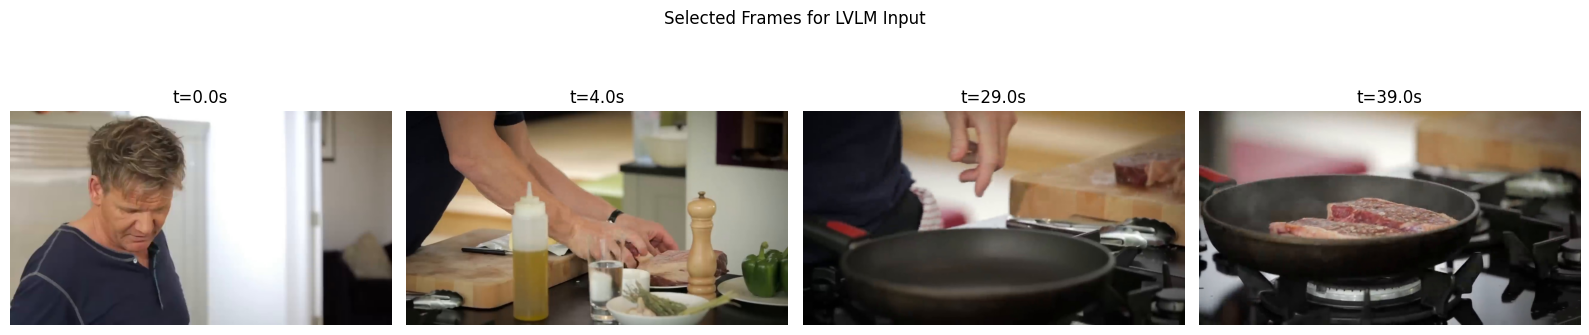

In [48]:
def select_frames_for_chunks(retrieved_chunks, frame_metadata, max_frames=8):
    """
    Select frames that are closest to the timestamps of retrieved chunks.
    Also add uniformly sampled frames for overall context.
    Returns list of (timestamp, PIL.Image) tuples.
    """
    # Get target timestamps from retrieved chunks
    target_timestamps = []
    for chunk in retrieved_chunks:
        # Use midpoint of the chunk
        mid = (chunk['start'] + chunk['end']) / 2
        target_timestamps.append(mid)

    # For each target, find nearest frame
    frame_ts = np.array([fm['timestamp'] for fm in frame_metadata])
    selected_indices = set()

    for ts in target_timestamps:
        nearest_idx = int(np.argmin(np.abs(frame_ts - ts)))
        selected_indices.add(nearest_idx)

    # Fill remaining slots with uniform samples across the video
    if len(selected_indices) < max_frames:
        uniform_indices = np.linspace(0, len(frame_metadata)-1,
                                      max_frames - len(selected_indices),
                                      dtype=int)
        for idx in uniform_indices:
            selected_indices.add(int(idx))

    # Sort by timestamp and limit to max_frames
    sorted_indices = sorted(list(selected_indices))[:max_frames]

    # Load frames as PIL images
    selected_frames = []
    for idx in sorted_indices:
        fm = frame_metadata[idx]
        img = Image.open(fm['path']).convert('RGB')
        selected_frames.append((fm['timestamp'], img))

    return selected_frames


selected_frames = select_frames_for_chunks(
    retrieved_chunks,
    frame_metadata,
    max_frames=CONFIG['max_frames_to_model']
)

print(f'Selected {len(selected_frames)} frames:')
for ts, img in selected_frames:
    print(f'  t={ts:.1f}s — {img.size}')

# Display frames in notebook
import matplotlib.pyplot as plt
n_frames = len(selected_frames)
fig, axes = plt.subplots(1, min(n_frames, 4), figsize=(16, 4))
if n_frames == 1:
    axes = [axes]
for ax, (ts, img) in zip(axes, selected_frames[:4]):
    ax.imshow(img)
    ax.set_title(f't={ts:.1f}s')
    ax.axis('off')
plt.suptitle('Selected Frames for LVLM Input')
plt.tight_layout()
plt.show()

In [49]:
def format_retrieved_context(retrieved_chunks):
    """
    Format retrieved chunks into a readable context block.
    """
    lines = ['=== Retrieved Video Context ===', '']

    for i, chunk in enumerate(retrieved_chunks):
        source_label = {
            'asr': '🎙️ Speech',
            'ocr': '📝 On-screen Text',
            'detection': '👁️ Detected Objects',
        }.get(chunk['source'], chunk['source'])

        lines.append(
            f"[{i+1}] {source_label} at "
            f"{chunk['start']:.1f}s–{chunk['end']:.1f}s:"
        )
        lines.append(f"    {chunk['text']}")
        lines.append('')

    return '\n'.join(lines)


def build_augmented_prompt(user_query, retrieved_chunks, selected_frames):
    """
    Build the final multi-modal prompt for the LVLM.
    """
    context_text = format_retrieved_context(retrieved_chunks)

    # Build content list: images + text
    content = []

    # Add frames as images
    for ts, img in selected_frames:
        content.append({'type': 'image', 'image': img})

    # Add text prompt
    full_text = (
        f"You are analyzing a video. You have been provided with {len(selected_frames)} "
        f"frames sampled from the video, plus extracted text context below.\n\n"
        f"{context_text}\n"
        f"=== User Question ===\n"
        f"{user_query}\n\n"
        f"Please answer the question based on BOTH the video frames AND the retrieved context above. "
        f"Be specific about timestamps when relevant."
    )
    content.append({'type': 'text', 'text': full_text})

    messages = [{'role': 'user', 'content': content}]
    return messages


print('✅ Prompt builder ready')
print('\nSample context that will be sent to LVLM:')
print(format_retrieved_context(retrieved_chunks))

✅ Prompt builder ready

Sample context that will be sent to LVLM:
=== Retrieved Video Context ===

[1] 🎙️ Speech at 25.0s–33.8s:
    Cooking a steak that's stone-cold in the centre. You're going to have to overcook it on the outside. Pan's just started smoking. Touch of oil in. All that round.

[2] 🎙️ Speech at 53.0s–62.6s:
    You want to render that down as well. That's it there. So hit that into the pan. Use the pan to your advantage. Tilt the pan. They're all that hot fat. Olive oil run down the back.

[3] 🎙️ Speech at 33.8s–43.5s:
    And then just lay the steaks away. Always away from me. And let the pan do the work. That's the kind of noise you want to hear in the pan every time. That nice sear.

[4] 🎙️ Speech at 43.5s–53.0s:
    Again, peritons. Turn it over very carefully. Literally 30 seconds of the pan. You can see the colour. Beautiful. That layer of fat on the back of the sirloin.

[5] 🎙️ Speech at 0.0s–8.2s:
    Right, the guide to cooking a perfect steak, hot pan. The se

In [50]:
import torch

def generate_answer(user_query, retrieved_chunks, selected_frames, lvlm, processor, max_new_tokens=512):
    """
    Stage 4: Dynamically Grounded Video Augmented Generation.
    Fixes token slicing mismatches by ensuring the visual frame count remains 1:1.
    """
    # 1. Build an un-polluted text context block
    context_str = ""
    for i, chunk in enumerate(retrieved_chunks):
        context_str += f"Context Chunk #{i+1} [Source: {chunk['source'].upper()}] (Time Window: {chunk['start']:.1f}s to {chunk['end']:.1f}s):\nText: {chunk['text']}\n\n"

    # Fully dynamic prompt - zero topic words hardcoded
    prompt_content = (
        f"You are an advanced video analysis system. Answer the user's question accurately using the provided transcript context and video keyframes.\n\n"
        f"--- RETRIEVED CONTEXT DATA ---\n"
        f"{context_str}"
        f"--- END RETRIEVED CONTEXT DATA ---\n\n"
        f"User Question: {user_query}\n\n"
        f"INSTRUCTIONS:\n"
        f"1. Rely strictly on facts mentioned in the text context chunks above to address the user question.\n"
        f"2. Explicitly state the exact timestamp or time window where the event occurs as documented in the source chunk metadata.\n"
        f"3. Do not quote the entire context string. Provide a direct, complete summary sentence.\n\n"
        f"Answer:"
    )

    # 2. Sanitize and sort all frames safely
    clean_frames = []
    for item in selected_frames:
        try:
            ts_raw = item[0]
            ts = float(ts_raw.replace('s', '').strip()) if isinstance(ts_raw, str) else float(ts_raw)
            clean_frames.append((ts, item[1]))
        except:
            continue

    chronological_frames = sorted(clean_frames, key=lambda x: x[0])

    # Dynamic Window Slicing: Extract frames matching the best retrieved text windows
    hd_frames = []
    if retrieved_chunks:
        for chunk in retrieved_chunks[:2]:
            c_start, c_end = chunk['start'], chunk['end']
            for ts, img in chronological_frames:
                if (c_start - 5.0) <= ts <= (c_end + 5.0):
                    if img not in hd_frames:
                        hd_frames.append(img)

    # Fallback to avoid empty lists
    if not hd_frames:
        hd_frames = [img for _, img in chronological_frames[:3]]

    # Safeguard memory limit allocations
    hd_frames = hd_frames[:4]

    # 3. Create Multi-Modal payload
    content_list = [{"type": "image", "image": img} for img in hd_frames]
    content_list.append({"type": "text", "text": prompt_content})

    messages = [{"role": "user", "content": content_list}]
    text_input = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    # CRITICAL: inputs must be processed using the EXACT matching images passed down downstream
    inputs = processor(text=text_input, images=hd_frames if hd_frames else None, padding=True, return_tensors='pt')
    inputs = {k: v.to(lvlm.device) for k, v in inputs.items()}

    # 4. Strict sequence execution tracking
    with torch.no_grad():
        with torch.amp.autocast(device_type='cuda'):
            outputs = lvlm.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                temperature=None,
                top_p=None,
                return_dict_in_generate=True,
                output_scores=False
            )

    generated_sequences = outputs.sequences[0]
    input_ids_length = inputs['input_ids'].shape[1]
    new_tokens = generated_sequences[input_ids_length:]

    return processor.decode(new_tokens, skip_special_tokens=True).strip()


def video_rag_pipeline(user_query, verbose=True):
    """
    Complete Video-RAG pipeline matching your original project layout.
    """
    print(f'\n{"="*60}')
    print(f'VIDEO-RAG PIPELINE')
    print(f'{"="*60}')
    print(f'Query: {user_query}\n')

    # ── Stage 1: Query Decoupling ────────────────────────────────────────────
    print('Stage 1: Query Decoupling...')
    raw_retrieval_query = decouple_query(user_query, lvlm, processor)

    # CLEANUP LAYER: Strip out redundant phrase double-quotes if generated by Stage 1
    retrieval_query = raw_retrieval_query.replace('"', '').strip()

    if verbose:
        print(f'  → Cleaned retrieval query: "{retrieval_query}"')

    # ── Stage 2: Retrieve Chunks ─────────────────────────────────────────────
    print('\nStage 2: Retrieving relevant chunks...')
    retrieved_chunks = retrieve(
        query=retrieval_query,
        bm25=bm25,
        faiss_index=faiss_index,
        embed_model=embed_model,
        corpus=corpus,
        texts=texts,
        top_k=CONFIG['top_k_retrieve'],
        mode=CONFIG['retrieval_mode']
    )
    if verbose:
        for chunk in retrieved_chunks:
            print(f"  #{chunk['retrieval_rank']+1} [{chunk['source']:9s}] "
                  f"[{chunk['start']:.1f}s] {chunk['text'][:60]}...")

    # ── Stage 3: Select Frames ───────────────────────────────────────────────
    print('\nStage 3: Selecting frames...')
    selected_frames = select_frames_for_chunks(
        retrieved_chunks, frame_metadata,
        max_frames=CONFIG['max_frames_to_model']
    )
    if verbose:
        timestamps = [f'{ts}' for ts, _ in selected_frames]
        print(f'  → {len(selected_frames)} frames at: {timestamps}')

    # ── Stage 4: Generate Answer ─────────────────────────────────────────────
    print('\nStage 4: Generating answer with LVLM...')

    answer = generate_answer(
        user_query, retrieved_chunks, selected_frames,
        lvlm, processor,
        max_new_tokens=512
    )

    print(f'\n{"─"*60}')
    print('ANSWER:')
    print(f'{"─"*60}')
    print(answer)
    print(f'{"─"*60}')

    result = {
        'user_query': user_query,
        'retrieval_query': retrieval_query,
        'retrieved_chunks': retrieved_chunks,
        'num_frames': len(selected_frames),
        'answer': answer,
    }
    return result

print("✅ System pipeline fully synchronized.")

✅ System pipeline fully synchronized.


In [57]:
USER_QUERY = ' when did gordon said the pan was smoking hot??'
result = video_rag_pipeline(USER_QUERY)


VIDEO-RAG PIPELINE
Query:  when did gordon said the pan was smoking hot??

Stage 1: Query Decoupling...
  → Cleaned retrieval query: "when did gordon say the pan was smoking hot"

Stage 2: Retrieving relevant chunks...
  #1 [asr      ] [53.0s] You want to render that down as well. That's it there. So hi...
  #2 [ocr      ] [150.0s] GORDON | RAMSAY'S | ULTIMATE | COOKERY | COURSE...
  #3 [ocr      ] [145.0s] GORDON | RAMSAY'S | ULTIMATE | COOKERY | COURSE...
  #4 [asr      ] [25.0s] Cooking a steak that's stone-cold in the centre. You're goin...
  #5 [asr      ] [0.0s] Right, the guide to cooking a perfect steak, hot pan. The se...

Stage 3: Selecting frames...
  → 7 frames at: ['0.0', '4.0', '29.0', '58.0', '75.0', '147.0', '150.0']

Stage 4: Generating answer with LVLM...

────────────────────────────────────────────────────────────
ANSWER:
────────────────────────────────────────────────────────────
Gordon mentioned that the pan was smoking hot at the time window of 25.0s to 33.8s.


In [55]:
TEST_QUERIES = [
    "What type of cookware does he use to sear the steak, and when does it first appear?",
    "At what timestamp does Gordon explicitly tell the viewer to lay the steaks away?",
    "When does he talk about rendering down the strip of fat on the side of the meat?",
    "What text graphic appears on screen when Gordon is summarizing his course at the very end?"
]